In [64]:
'''
The WordNet Mammal subtree (https://wordnet.princeton.edu)
data from https://papers.nips.cc/paper_files/paper/2017/hash/59dfa2df42d9e3d41f5b02bfc32229dd-Abstract.html 

Get distance matrix for embedding 
After embedding, visualize the embedding
'''
import networkx as nx
import pylab as plt
import numpy as np
import pandas as pd
import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import seaborn as sn
from scipy import stats
import textalloc as ta

In [65]:
# plot parameters
plt.style.use('../figures/my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)

In [66]:
# create graph from data
df = pd.read_csv('./mammal_closure.csv')
Graphtype = nx.Graph()
G = nx.from_pandas_edgelist(df,'id1','id2', ['weight'],create_using=Graphtype)

In [67]:
df.iloc[np.where(df['id1'] == 'bengal_tiger.n.01')[0]]

,id1,id2,weight
0,bengal_tiger.n.01,carnivore.n.01,1
34,bengal_tiger.n.01,feline.n.01,1
86,bengal_tiger.n.01,big_cat.n.01,1
1413,bengal_tiger.n.01,mammal.n.01,1
3626,bengal_tiger.n.01,tiger.n.02,1
5642,bengal_tiger.n.01,placental.n.01,1


In [68]:
nodes1 = np.array(G.nodes)

In [69]:
# appearence: number of ancesters
app = df.groupby('id1').count()['id2']
app['mammal.n.01'] = 0

In [70]:
# only keep link to the nearest ancester (the ancester with the smallest number )
df2 = []
for node in nodes1:
    temp = df.iloc[np.where(df['id1'] == node)[0]]
    if len(temp) >0 :
        df2.append(temp.iloc[np.argmax(app[temp['id2']])])
df2 = pd.DataFrame(df2)
Graphtype = nx.Graph()
G2 = nx.from_pandas_edgelist(df2,'id1','id2', ['weight'],create_using=Graphtype)

In [71]:
nodes2 = np.array(G2.nodes)

In [72]:
length2 = dict(nx.all_pairs_dijkstra_path_length(G2))

In [73]:
dmat = np.zeros((len(nodes2),len(nodes2)))
for i in range(len(dmat)):
    for j in range(len(dmat)):
        dmat[i][j] = length2[nodes2[i]][nodes2[j]]

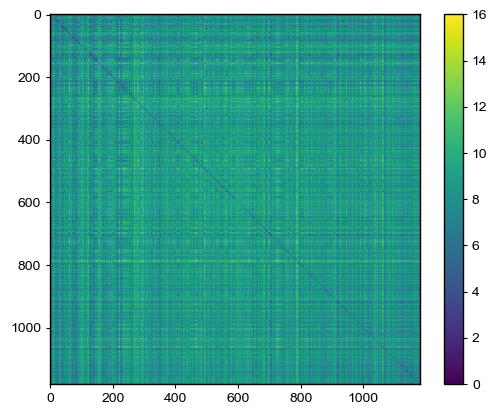

In [74]:
plt.imshow(dmat)
plt.colorbar()

In [75]:
# np.savetxt('../data/DistMat_mammalwords/DistMat_mammalwords.txt',dmat)

In [76]:
nx.diameter(G2)

16

In [77]:
pcoords = np.loadtxt('../MultiscalehMDS_distance/result/DistMat_mammalwords/cls_0.4_Nn_60_Nd_2_min_1_max_300_coords_1180.txt')

In [78]:
inds = np.loadtxt('../MultiscalehMDS_distance/result/DistMat_mammalwords/cls_0.4_Nn_60_Nd_2_min_1_max_300_inds_after_prep.txt')
pcoords = pcoords[np.argsort(inds)]

In [79]:
curvature= pd.read_csv('../MultiscalehMDS_distance/result/DistMat_mammalwords/cls_0.4_Nn_60_Nd_2_min_1_max_300_metrics.csv')['curvature'][0]

In [80]:
# average distortion
dmat = np.loadtxt('../data/DistMat_mammalwords/DistMat_mammalwords.txt')
dmat = dmat/np.max(dmat)*2.0
dmatemb = emb.get_dmat_poin(pcoords)
dmatemb = dmatemb/curvature

In [81]:
# average distortion
def avedit(dmat1,dmat2):
    offset = abs(dmat2-dmat1)
    N_sample = len(offset)
    dist = offset[np.triu_indices(N_sample, k=1)]/dmat1[np.triu_indices(N_sample, k=1)]
    return np.mean(dist)

In [82]:
distortion = avedit(dmat,dmatemb)

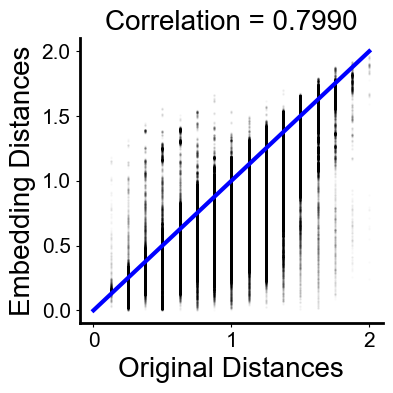

In [83]:
# shepard diagram
fig,axs = plt.subplots(1,1,figsize=(4,4))

N_sample = len(dmat)

axs.scatter(dmat[np.triu_indices(N_sample, k=1)], 
               dmatemb[np.triu_indices(N_sample, k=1)],
               s=1,alpha=0.01,c='k')
stat,p = stats.pearsonr(dmat[np.triu_indices(len(dmat),1)],dmatemb[np.triu_indices(len(dmat),1)])
axs.set_title('Correlation = %.4f'%stat,fontsize=20)
axs.plot(np.arange(0,3),np.arange(0,3),c='b',linewidth=3)
width=2
axs.spines['bottom'].set_linewidth(width)
axs.spines['left'].set_linewidth(width)
axs.spines[['right','top']].set_visible(False)

axs.tick_params(axis="x", labelsize=15)  
axs.tick_params(axis="y", labelsize=15)
axs.set_xlabel('Original Distances', fontsize=20)
axs.set_ylabel('Embedding Distances', fontsize=20)
plt.tight_layout()
clean_axis(axs)



In [84]:
df_toplot = pd.DataFrame({'x':pcoords[:,0],'y':pcoords[:,1]},index=nodes2)

In [85]:
df_toplot = pd.concat([df_toplot,app],axis=1)

In [86]:
# most number of childrens
app2 = df.groupby('id2').count()['id1']

In [94]:
metadata = pd.DataFrame(index=nodes2)
# rename id1 column to num_children
app2 = app2.rename('num_children')
metadata = pd.concat([metadata,app2],axis=1)
metadata.to_csv('../data/metadata/mammalwords_metadata.csv',index=True)

In [33]:
def to_native(coords):
    rs = np.linalg.norm(coords,axis=1)
    native_rs = 2.0*np.arctanh(rs)
    coords_new = (coords.T*native_rs).T
    return coords_new

In [34]:
native = to_native(pcoords)
df_toplot['nativex'] = native[:,0]
df_toplot['nativey'] = native[:,1]

In [58]:
namelist = app2.sort_values(ascending=False).index[:30]
print(namelist)

Index(['mammal.n.01', 'placental.n.01', 'carnivore.n.01', 'ungulate.n.01',
       'canine.n.02', 'dog.n.01', 'even-toed_ungulate.n.01', 'ruminant.n.01',
       'rodent.n.01', 'bovid.n.01', 'odd-toed_ungulate.n.01', 'equine.n.01',
       'primate.n.02', 'hunting_dog.n.01', 'horse.n.01', 'aquatic_mammal.n.01',
       'feline.n.01', 'working_dog.n.01', 'musteline_mammal.n.01', 'bat.n.01',
       'bovine.n.01', 'cat.n.01', 'monkey.n.01', 'terrier.n.01',
       'metatherian.n.01', 'marsupial.n.01', 'antelope.n.01',
       'carnivorous_bat.n.01', 'cetacean.n.01', 'whale.n.02'],
      dtype='object', name='id2')


In [36]:
# add columns to df_toplot: distance to "mammal.n.01"
len_to_mammal_dict = length2['mammal.n.01']
df_toplot['len_to_mammal'] = [len_to_mammal_dict[node] for node in df_toplot.index]
leave_to_compare = 'irish_water_spaniel.n.01'
len_to_terrier_dict = length2[leave_to_compare]
df_toplot['len_to_leave'] = [len_to_terrier_dict[node] for node in df_toplot.index]
df_toplot.head()

,x,y,id2,nativex,nativey,len_to_mammal,len_to_leave
bengal_tiger.n.01,-0.537903,0.836108,6,-3.140635,4.881749,6,11
tiger.n.02,-0.527115,0.830708,5,-2.535314,3.995530,5,10
carnivore.n.01,-0.307603,0.438578,2,-0.367955,0.524626,2,7
placental.n.01,-0.145200,-0.001187,1,-0.042468,-0.000347,1,8
anthropoid_ape.n.01,0.698501,-0.210038,4,1.295631,-0.389594,4,11


In [ ]:
# new metric: different branches from the 1st/2nd order child of mammal.n.01
level = 3
cats = app2.sort_values(ascending=False).index[:30]
cats = [node for node in cats if df_toplot.loc[node,'len_to_mammal'] == level]
print(len(cats))

8


In [38]:
df_toplot['category'] = None
for cat in cats:
    df_toplot.loc[df.iloc[np.where(df['id2'] == cat)[0]].id1,'category'] = cat
df_toplot['category'] = df_toplot['category'].fillna('other')
print(len(df_toplot['category'].unique()))

9


Unique categories: ['feline.n.01' 'other' 'canine.n.02' 'even-toed_ungulate.n.01'
 'odd-toed_ungulate.n.01' 'monkey.n.01' 'cetacean.n.01'
 'musteline_mammal.n.01' 'carnivorous_bat.n.01']


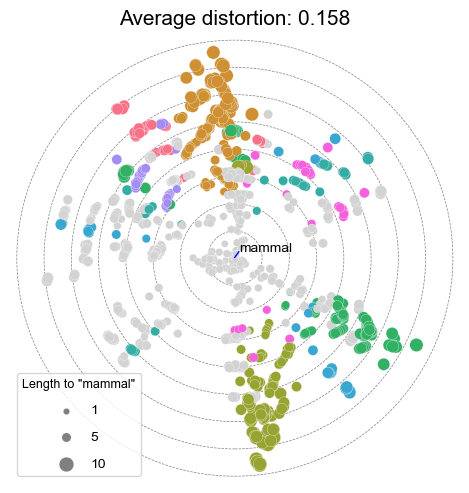

In [ ]:
# plot edges: native coordinate
fig,ax = plt.subplots(figsize=(6,5))

mode = 'native'

# plot circles at (0,0) of different radius to indicate hyperbolic
maxradius = np.ceil(np.max(np.sqrt(df_toplot['nativex']**2 + df_toplot['nativey']**2)))
rads = np.arange(1,maxradius + 1, 1)
if mode == 'poin':
    rads = np.tanh(rads/2.0)
for r in rads:
    circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', linewidth=0.5)
    ax.add_artist(circle)

if mode == 'poin':
    df_toplot['xtoplot'] = df_toplot['x']
    df_toplot['ytoplot'] = df_toplot['y']
    namelist = app2.sort_values(ascending=False).index[:30]
    for i in range(len(df)):
        name1,name2 = df.iloc[i]['id1'],df.iloc[i]['id2']
        ax.plot([df_toplot.loc[name1]['xtoplot'],df_toplot.loc[name2]['xtoplot']],
                [df_toplot.loc[name1]['ytoplot'],df_toplot.loc[name2]['ytoplot']],color='grey',
                linewidth=0.01)

elif mode == 'native':
    df_toplot['xtoplot'] = df_toplot['nativex']
    df_toplot['ytoplot'] = df_toplot['nativey']
    namelist = ['mammal.n.01',]

categories = df_toplot["category"].unique()
print("Unique categories:", categories)
# drop 'other' category if it exists
if 'other' in categories:
    categories = categories[categories != 'other']

palette = sn.color_palette(palette='husl',n_colors=len(categories))

category2color = dict(zip(categories, palette))
category2color['other'] = 'lightgray'  # Assign a color for 'other' category

colors = df_toplot["category"].map(category2color)

sc = ax.scatter(
    df_toplot["xtoplot"], df_toplot["ytoplot"],
    c=colors,
    s=1.2**(df_toplot["len_to_mammal"])*18, # size by distance to mammal
    # cmap="viridis",   
    # s=10,
    alpha=1.0,
    edgecolors='white',
    linewidths=0.2
)

for size in [1, 5, 10]:
    ax.scatter([], [], s=1.2**size*18, c='gray', alpha=1.0,edgecolors='white',linewidths=0.2,
               label=str(round(size,2)))
ax.legend(scatterpoints=1, frameon=True, labelspacing=1, title='Length to "mammal"')


ta.allocate_text(fig,ax,df_toplot.loc[namelist]['xtoplot'],
                 df_toplot.loc[namelist]['ytoplot'],
            [name.split('.')[0] for name in namelist],
            max_distance=0.1,
            min_distance=0.01,
            margin=0.0,
            linewidth=1,
            nbr_candidates=200,
            linecolor='blue',
                textsize=10,
                avoid_label_lines_overlap=True,
                seed=3)


# set x and y limits
ax.set_xlim(-rads[-1]-0.25, rads[-1]+0.25)
ax.set_ylim(-rads[-1]-0.25, rads[-1]+0.25)

# remove axis and box
ax.set_axis_off()
# set aspect ratio to equal
ax.set_aspect('equal', adjustable='box')
ax.set_title('Average distortion: %.3f'%distortion,fontsize=15)

plt.tight_layout()



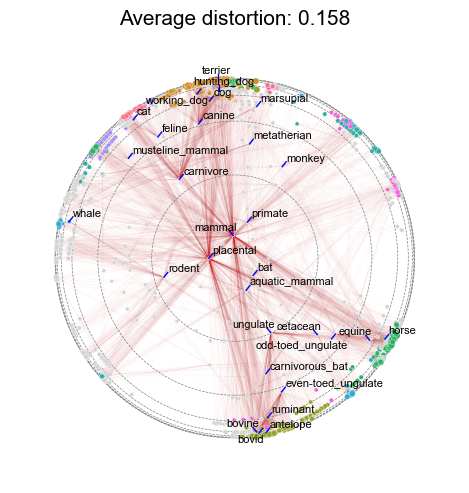

In [ ]:
# plot edges
fig,ax = plt.subplots(figsize=(6,5))
mode = 'poin'
# plot circles at (0,0) of different radius to indicate hyperbolic
maxradius = np.ceil(np.max(np.sqrt(df_toplot['nativex']**2 + df_toplot['nativey']**2)))
rads = np.arange(1,maxradius + 1, 1)
if mode == 'poin':
    rads = np.tanh(rads/2.0)
for r in rads:
    circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', linewidth=0.5)
    ax.add_artist(circle)

for i in range(len(df)):
    name1,name2 = df.iloc[i]['id1'],df.iloc[i]['id2']
    ax.plot([df_toplot.loc[name1]['x'],df_toplot.loc[name2]['x']],
             [df_toplot.loc[name1]['y'],df_toplot.loc[name2]['y']],color='tab:red',
            linewidth=0.01,zorder = 0)

sc = ax.scatter(
    df_toplot["x"], df_toplot["y"],
    c=colors,
    s=1.2**(df_toplot["len_to_mammal"])*4, # size by distance to mammal
    alpha=1.0,
    edgecolors='white',
    linewidths=0.2
)

namelist = app2.sort_values(ascending=False).index[:30]


ta.allocate_text(fig,ax,df_toplot.loc[namelist]['x'],
                 df_toplot.loc[namelist]['y'],
            [name.split('.')[0] for name in namelist],
            max_distance=0.1,
            min_distance=0.01,
            margin=0.0,
            linewidth=1,
            nbr_candidates=200,
            linecolor='blue',
                textsize=8,
                avoid_label_lines_overlap=True,
                seed=3)

# set x and y limits
ax.set_xlim(-rads[-1]-0.25, rads[-1]+0.25)
ax.set_ylim(-rads[-1]-0.25, rads[-1]+0.25)

# remove axis and box
ax.set_axis_off()
# set aspect ratio to equal
ax.set_aspect('equal', adjustable='box')
ax.set_title('Average distortion: %.3f'%distortion,fontsize=15)

plt.tight_layout()